# Рубежный контроль №1
## Технологии машинного обучения


**Студент:** Омарова Заира 
**Группа:** ИУ5Ц-81Б  
**Вариант:** 27 (Задача №4, Набор данных №3)  

##  Описание набора данных

Датасет содержит 150 000 записей и включает следующие признаки:

- City — город проживания  
- Gender — пол  
- Age — возраст  
- Income — доход  
- Illness — наличие заболевания  

Цель работы — провести разведочный анализ данных (EDA), изучить распределения признаков и выявить зависимости между ними.

### Задача №4

Для заданного набора данных постройте основные графики, входящие в этап разведочного анализа данных. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Какие графики Вы построили и почему? Какие выводы о наборе данных Вы можете сделать на основании построенных графиков?

### Допольнительное требование для группы ИУ5Ц-81Б:

Для пары произвольных колонок данных построить график "Диаграмма рассеяния".

In [3]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\zazao\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


## Загрузка и подготовка данных

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("toy_dataset.csv")

# удаляем ID
df = df.drop(columns=['Number'])

df.head()

,City,Gender,Age,Income,Illness
0,Dallas,Male,41,40367.0,No
1,Dallas,Male,54,45084.0,No
2,Dallas,Male,42,52483.0,No
3,Dallas,Male,40,40941.0,No
4,Dallas,Male,46,50289.0,No


## Первичный анализ данных

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   City     150000 non-null  object 
 1   Gender   150000 non-null  object 
 2   Age      150000 non-null  int64  
 3   Income   150000 non-null  float64
 4   Illness  150000 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 5.7+ MB


,Age,Income
count,150000.000000,150000.000000
mean,44.950200,91252.798273
std,11.572486,24989.500948
min,25.000000,-654.000000
25%,35.000000,80867.750000
50%,45.000000,93655.000000
75%,55.000000,104519.000000
max,65.000000,177157.000000


### Проверка пропусков

In [6]:
df.isnull().sum()

City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

**Вывод:**
- Датасет содержит 150 000 строк  
- Пропуски отсутствуют  
- Все признаки корректны для анализа  

## Анализ распределения признаков

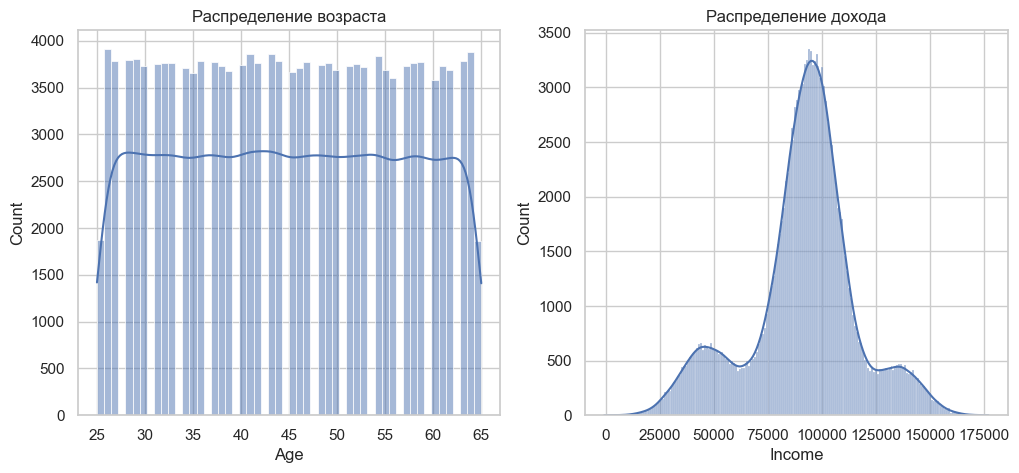

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True)
plt.title('Распределение возраста')

plt.subplot(1,2,2)
sns.histplot(df['Income'], kde=True)
plt.title('Распределение дохода')

plt.show()

**Вывод:**
- Возраст распределён достаточно равномерно  
- Доход имеет широкий диапазон значений  
- Наблюдается разброс значений дохода  

##  Анализ выбросов

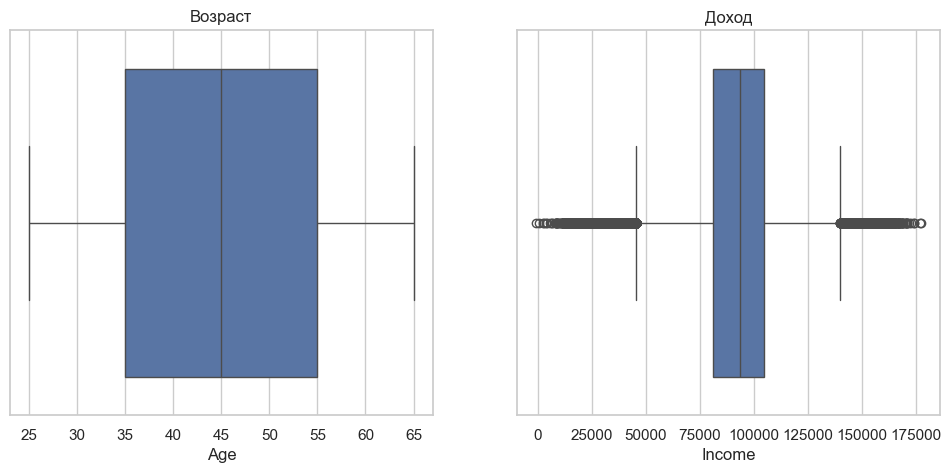

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Age'])
plt.title('Возраст')

plt.subplot(1,2,2)
sns.boxplot(x=df['Income'])
plt.title('Доход')

plt.show()

**Вывод:**
- В признаке Income присутствуют выбросы  
- Возможны отрицательные значения дохода  
- Возраст распределён более стабильно  

##  Анализ категориальных признаков

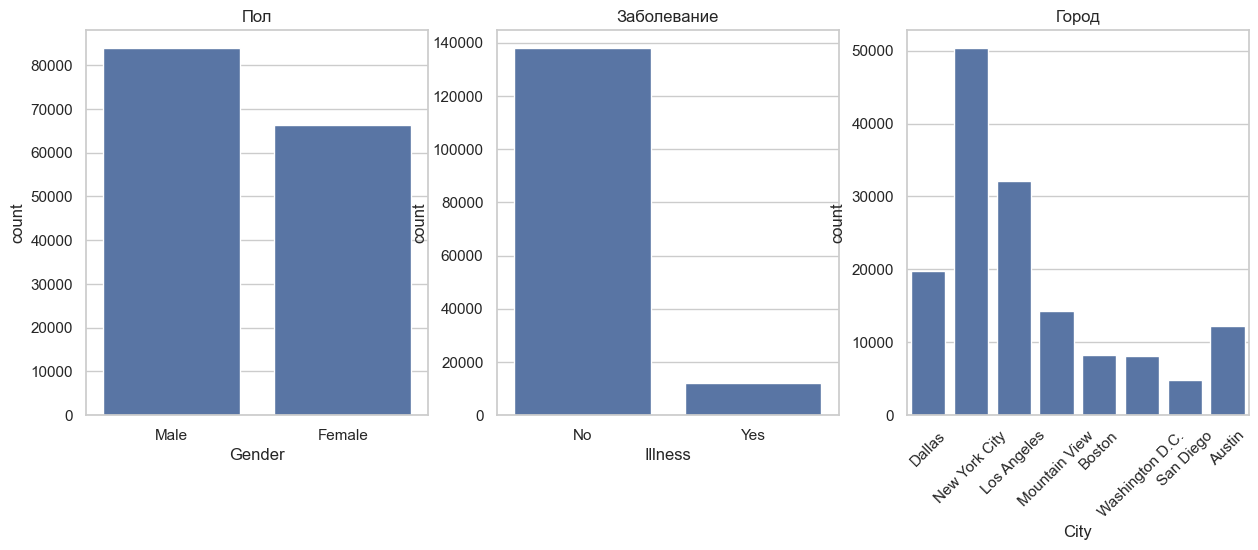

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.countplot(x='Gender', data=df)
plt.title('Пол')

plt.subplot(1,3,2)
sns.countplot(x='Illness', data=df)
plt.title('Заболевание')

plt.subplot(1,3,3)
sns.countplot(x='City', data=df)
plt.title('Город')
plt.xticks(rotation=45)

plt.show()

**Вывод:**
- Пол распределён примерно равномерно  
- Города представлены равномерно  
- Признак Illness показывает наличие дисбаланса между значениями  

## Анализ зависимости Age и Income

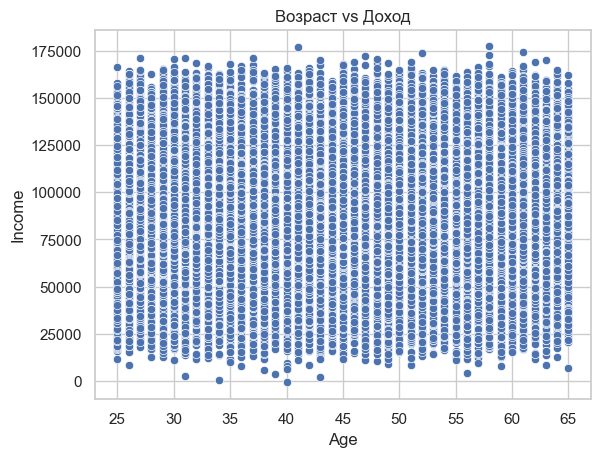

In [10]:
sns.scatterplot(x='Age', y='Income', data=df)
plt.title('Возраст vs Доход')
plt.show()

**Вывод:**
- Явной линейной зависимости между возрастом и доходом не наблюдается  
- Возможна слабая тенденция роста дохода с возрастом  

## Анализ влияния категориальных признаков

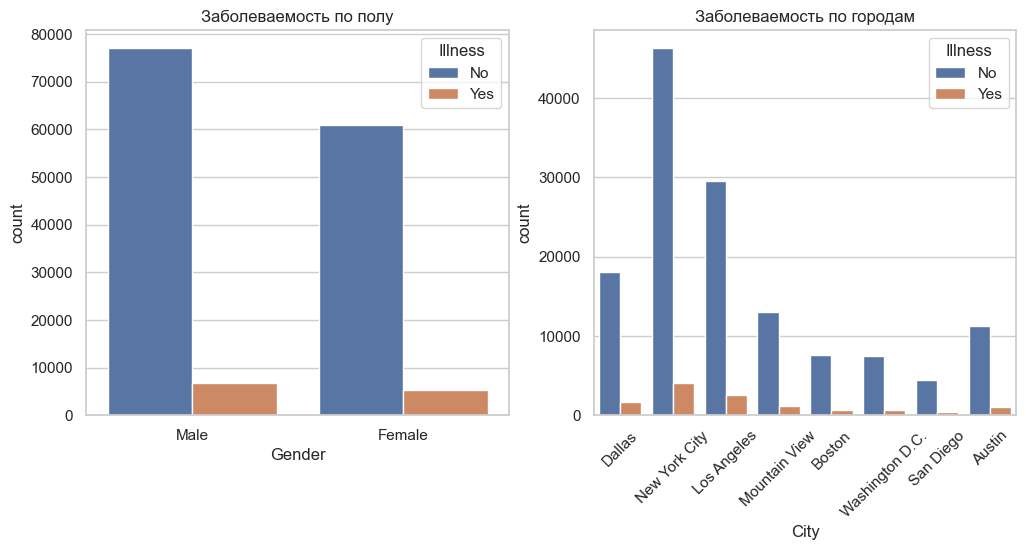

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='Gender', hue='Illness', data=df)
plt.title('Заболеваемость по полу')

plt.subplot(1,2,2)
sns.countplot(x='City', hue='Illness', data=df)
plt.title('Заболеваемость по городам')
plt.xticks(rotation=45)

plt.show()

**Вывод:**
- Заболеваемость может различаться в зависимости от пола  
- В некоторых городах наблюдаются различия в уровне заболеваемости  

##  Сравнение дохода по группам

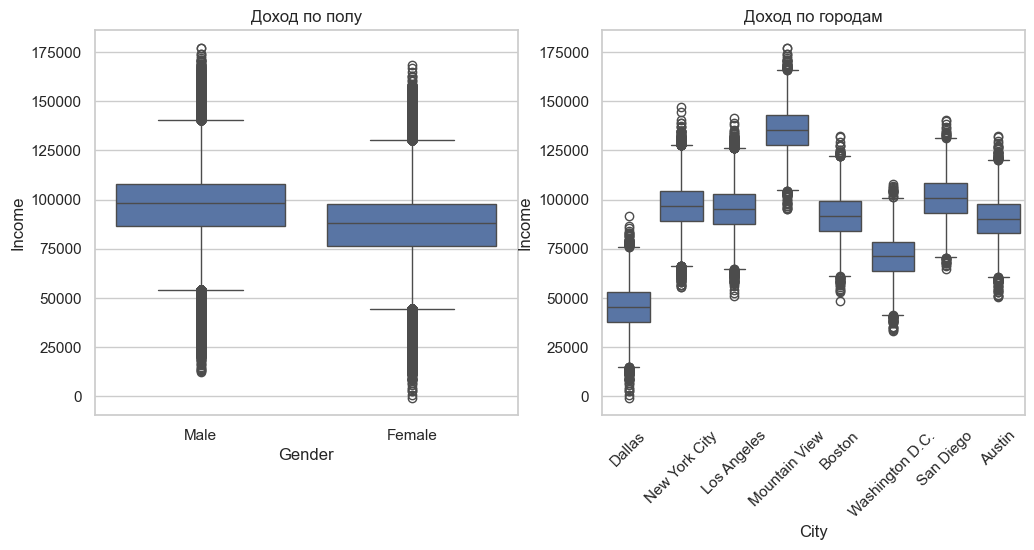

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='Gender', y='Income', data=df)
plt.title('Доход по полу')

plt.subplot(1,2,2)
sns.boxplot(x='City', y='Income', data=df)
plt.title('Доход по городам')
plt.xticks(rotation=45)

plt.show()

**Вывод:**
- Доход варьируется между городами  
- Существенных различий между полами не наблюдается  

##  Корреляционный анализ

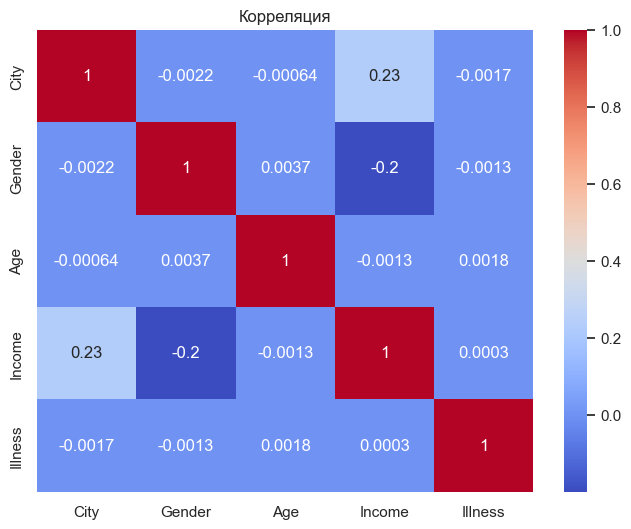

In [13]:
df_encoded = df.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 0, 'Female': 1})
df_encoded['Illness'] = df_encoded['Illness'].map({'No': 0, 'Yes': 1})
df_encoded['City'] = df_encoded['City'].astype('category').cat.codes

plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция')
plt.show()

**Вывод:**
- Сильных корреляций между признаками не выявлено  
- Age и Income имеют слабую связь  

## Диаграмма рассеяния (Scatter Plot)

Для выполнения дополнительного требования была построена диаграмма рассеяния для пары признаков Age и Income.

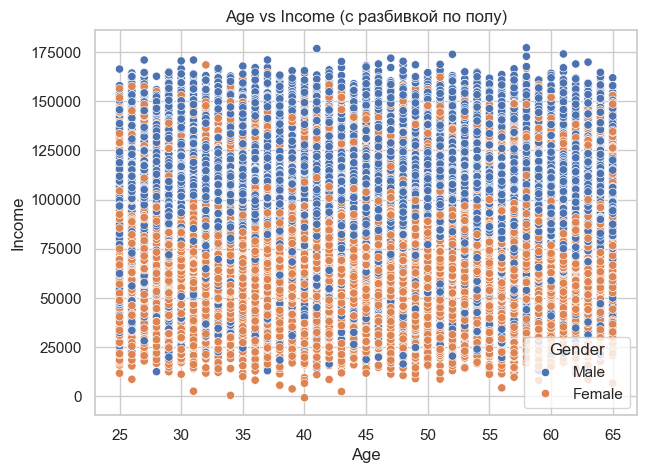

In [15]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Age', y='Income', hue='Gender', data=df)

plt.title('Age vs Income (с разбивкой по полу)')
plt.show()

**Почему выбраны эти признаки:**
- оба признака являются числовыми  
- интересно проверить зависимость дохода от возраста  

**Вывод:**
- явной линейной зависимости между возрастом и доходом не наблюдается  
- присутствует большой разброс значений дохода  
- возможна слабая тенденция роста дохода с возрастом  

##  Итоговые выводы

В ходе разведочного анализа данных были построены следующие графики:
- гистограммы (распределения признаков)
- boxplot (анализ выбросов)
- countplot (категориальные признаки)
- scatter plot (зависимости)
- heatmap (корреляции)

Основные выводы:
- данные не содержат пропусков  
- возраст распределён равномерно  
- доход имеет широкий диапазон и содержит выбросы  
- сильных зависимостей между признаками не обнаружено  
- наблюдаются различия по городам и признаку заболевания  

Датасет является синтетическим и подходит для демонстрации методов разведочного анализа данных.